<a href="https://colab.research.google.com/github/Paulo-JPassos/Machine_Learning/blob/main/Atividade2Detec%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ATIVIDADE 2 - DETECÇÃO DE OBJETOS

Guilherme de Andrade

Klauber Barros

Lucas Silva

Paulo Jorge

# 1. Parafusos

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

Limiar encontrado pelo OTSU: 204.0


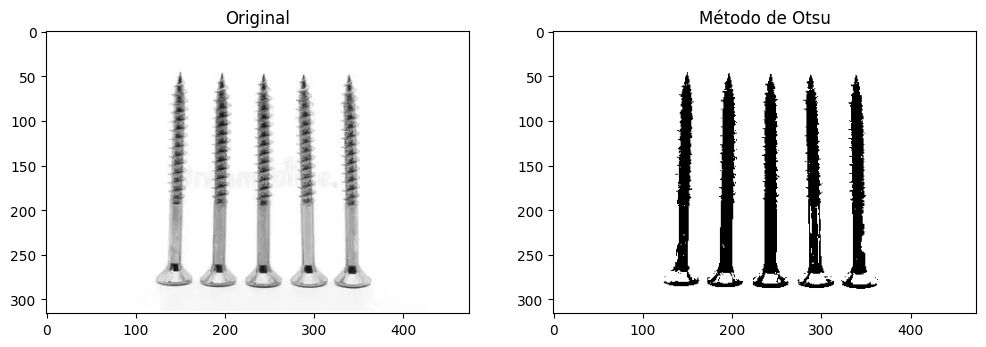

In [2]:
#Método OTSU

url = "https://tse1.mm.bing.net/th/id/OIP.AR21aEW9ua2UZSKkr0TzkQHaE8?rs=1&pid=ImgDetMain&o=7&rm=3"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

otsu_value, otsu = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Limiar encontrado pelo OTSU:", otsu_value)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(img, cmap= "gray")
plt.title("Original")

plt.subplot(122)
plt.imshow(otsu, cmap= "gray")
plt.title("Método de Otsu")

plt.show()

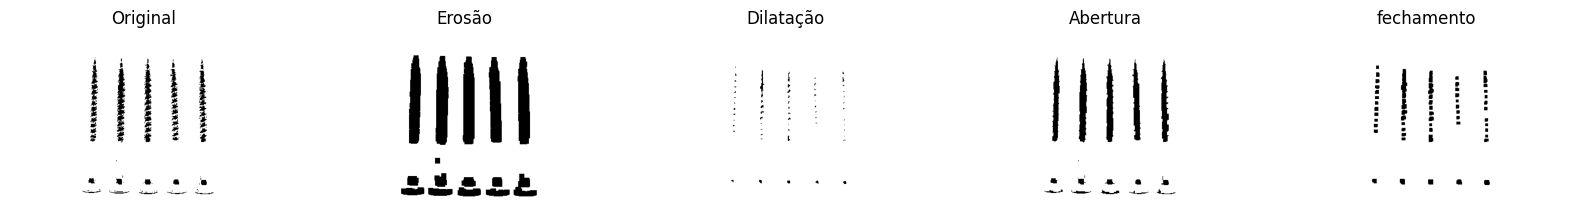

In [3]:
#Operações Morfologicas

# Carregar imagem
url = "https://tse1.mm.bing.net/th/id/OIP.AR21aEW9ua2UZSKkr0TzkQHaE8?rs=1&pid=ImgDetMain&o=7&rm=3"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(
    img,
    150,
    255,
    cv2.THRESH_BINARY
)

kernel = np.ones((5,5),np.uint8)

erosion = cv2.erode(binary, kernel, iterations=2) # Aumentei as iterações de erosão para 2

dilation = cv2.dilate(binary,kernel, iterations=1)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closing= cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

fig, ax = plt.subplots(1,5, figsize=(20,5))

title = [
    "Original",
    "Erosão",
    "Dilatação",
    "Abertura",
    "fechamento"
]

images = [
    binary,
    erosion,
    dilation,
    opening,
    closing
]

for i in range(5):
  ax[i].imshow(images[i],cmap="gray")
  ax[i].set_title(title[i])
  ax[i].axis("off")

plt.show()

Quantidade: 5


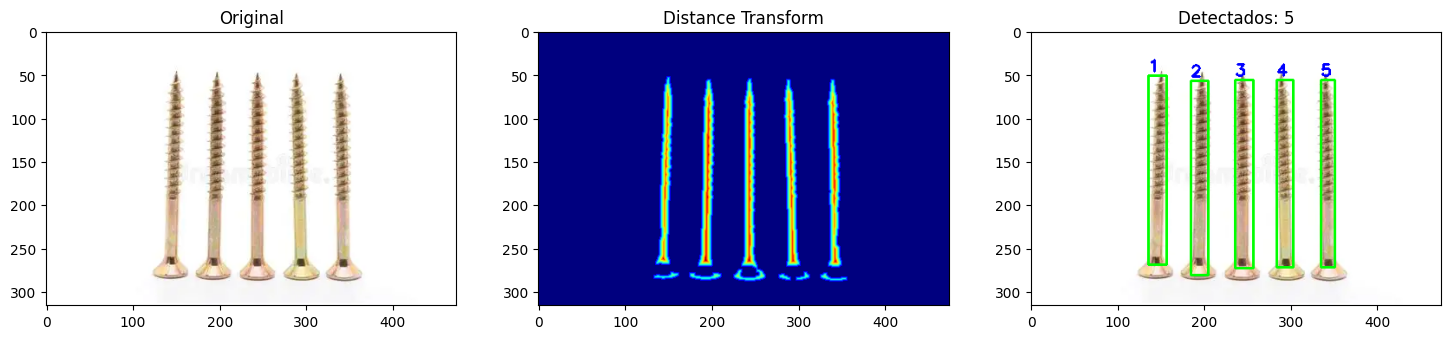

In [4]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

# ====================================
# Baixa a imagem
# ====================================

url = "https://tse1.mm.bing.net/th/id/OIP.AR21aEW9ua2UZSKkr0TzkQHaE8?rs=1&pid=ImgDetMain&o=7&rm=3"

resp = requests.get(url)
img = cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_COLOR)

original = img.copy()

# ====================================
# Escala de cinza
# ====================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray,(5,5),0)

# ====================================
# Threshold
# ====================================

_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3,3),np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# ====================================
# Background
# ====================================

sure_bg = cv2.dilate(opening,kernel,iterations=3)

# ====================================
# Distance Transform
# ====================================

dist = cv2.distanceTransform(opening, cv2.DIST_L2,5)

_, sure_fg = cv2.threshold(
    dist,
    0.35*dist.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg,sure_fg)

# ====================================
# Watershed
# ====================================

num_markers, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown==255] = 0

markers = cv2.watershed(img,markers)

count = 0

for label in np.unique(markers):

    if label <= 1:
        continue

    mask = np.uint8(markers==label)

    cnts,_ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(cnts)==0:
        continue

    c = max(cnts,key=cv2.contourArea)

    area = cv2.contourArea(c)

    if area < 300:
        continue

    x,y,w,h = cv2.boundingRect(c)

    cv2.rectangle(
        original,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

    count += 1

    cv2.putText(
        original,
        str(count),
        (x,y-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

print("Quantidade:",count)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(132)
plt.imshow(dist,cmap='jet')
plt.title("Distance Transform")

plt.subplot(133)
plt.imshow(cv2.cvtColor(original,cv2.COLOR_BGR2RGB))
plt.title(f"Detectados: {count}")

plt.show()

#2. Comprimidos

Limiar encontrado pelo OTSU: 169.0


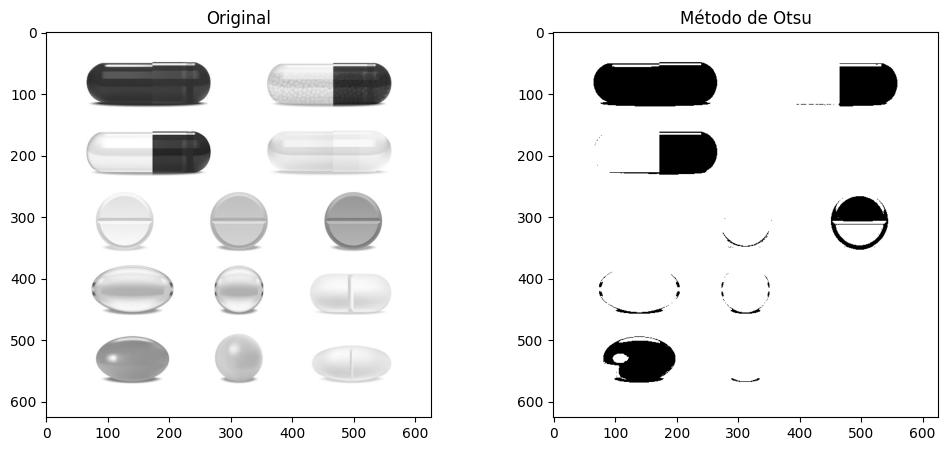

In [5]:
#Método OTSU
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

url = "https://img.magnific.com/vetores-gratis/conjunto-de-comprimidos-e-capsulas-de-medicamento-colorido_1284-32529.jpg"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

otsu_value, otsu = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Limiar encontrado pelo OTSU:", otsu_value)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(img, cmap= "gray")
plt.title("Original")

plt.subplot(122)
plt.imshow(otsu, cmap= "gray")
plt.title("Método de Otsu")

plt.show()

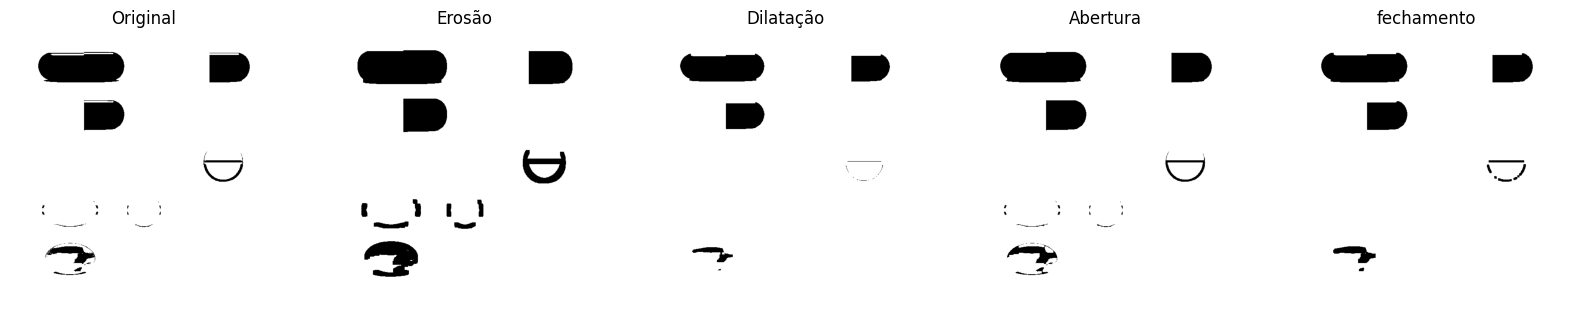

In [6]:
#Operações Morfologicas
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# Carregar imagem
url = "https://img.magnific.com/vetores-gratis/conjunto-de-comprimidos-e-capsulas-de-medicamento-colorido_1284-32529.jpg"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(
    img,
    150,
    255,
    cv2.THRESH_BINARY
)

kernel = np.ones((5,5),np.uint8)

erosion = cv2.erode(binary, kernel, iterations=2) # Aumentei as iterações de erosão para 2

dilation = cv2.dilate(binary,kernel, iterations=1)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closing= cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

fig, ax = plt.subplots(1,5, figsize=(20,5))

title = [
    "Original",
    "Erosão",
    "Dilatação",
    "Abertura",
    "fechamento"
]

images = [
    binary,
    erosion,
    dilation,
    opening,
    closing
]

for i in range(5):
  ax[i].imshow(images[i],cmap="gray")
  ax[i].set_title(title[i])
  ax[i].axis("off")

plt.show()

Objetos detectados: 10


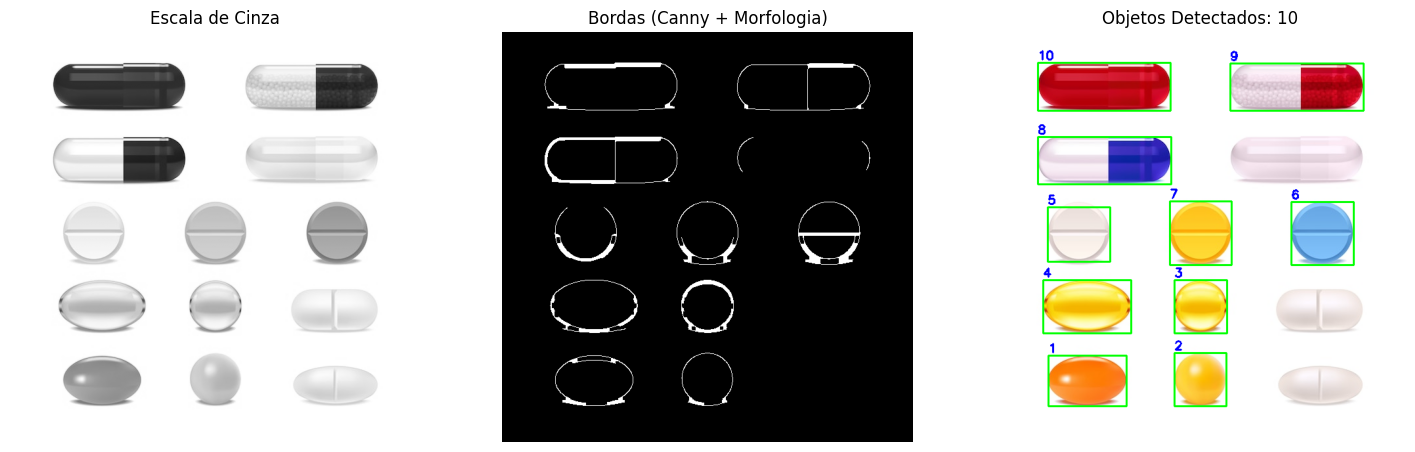

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ==========================
# Carregar imagem
# ==========================

url = "https://img.magnific.com/vetores-gratis/conjunto-de-comprimidos-e-capsulas-de-medicamento-colorido_1284-32529.jpg"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_COLOR)
original = img.copy()

# ==========================
# ESCALA DE CINZA (única etapa base)
# ==========================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# Realce de bordas (sem binarização)
# ==========================

blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

# ==========================
# Fechamento morfológico para unir bordas
# ==========================

kernel = np.ones((3,3), np.uint8)

closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# ==========================
# Contornos diretamente das bordas
# ==========================

contours, _ = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contador = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    # remove ruídos
    if area < 300:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    contador += 1

    cv2.rectangle(
        original,
        (x, y),
        (x+w, y+h),
        (0,255,0),
        2
    )

    cv2.putText(
        original,
        str(contador),
        (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

print("Objetos detectados:", contador)

# ==========================
# Exibir resultados
# ==========================

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(gray, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")

plt.subplot(132)
plt.imshow(closed, cmap="gray")
plt.title("Bordas (Canny + Morfologia)")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos Detectados: {contador}")
plt.axis("off")

plt.show()

Objetos detectados: 13


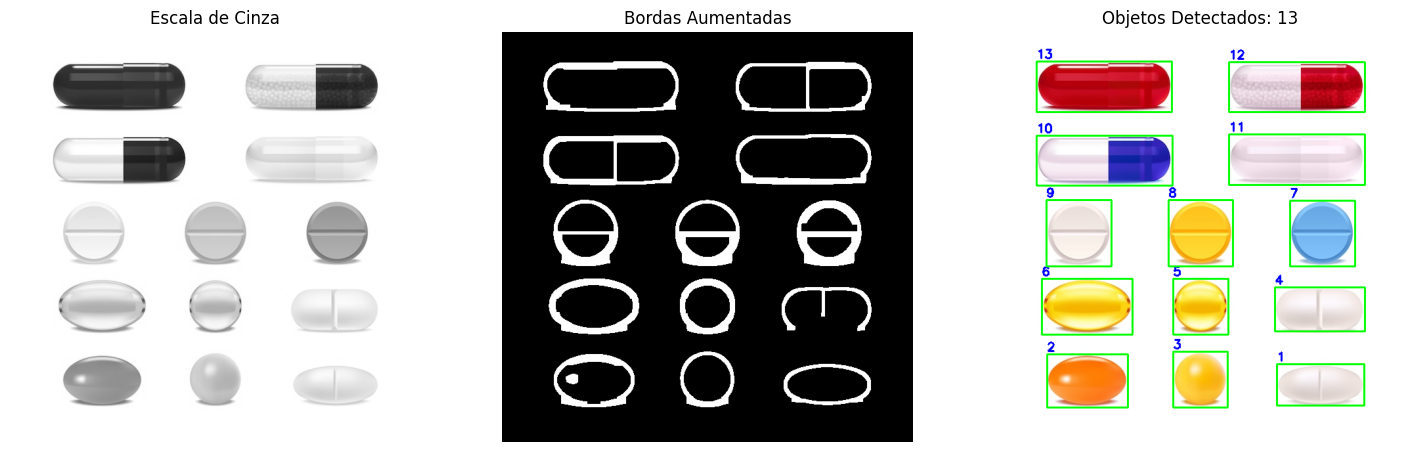

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ==========================
# Carregar imagem
# ==========================

url = "https://img.magnific.com/vetores-gratis/conjunto-de-comprimidos-e-capsulas-de-medicamento-colorido_1284-32529.jpg"

resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)

img = cv2.imdecode(image, cv2.IMREAD_COLOR)

if img is None:
    raise ValueError("Erro ao carregar a imagem. Verifique o link informado.")

original = img.copy()

# ==========================
# Converter para escala de cinza
# ==========================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# Aplicar suavização
# ==========================

blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ==========================
# Detectar bordas com Canny
# Valores menores deixam a detecção mais sensível
# ==========================

edges = cv2.Canny(blur, 25, 110)

# ==========================
# Aumentar a espessura das bordas
# ==========================

kernel = np.ones((5, 5), np.uint8)

dilated = cv2.dilate(edges, kernel, iterations=1)

# ==========================
# Fechamento morfológico
# Une pequenas falhas nas bordas
# ==========================

closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel, iterations=2)

# ==========================
# Encontrar contornos
# ==========================

contours, _ = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contador = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    # Remove ruídos pequenos
    if area < 150:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    # Evita contar regiões muito pequenas ou deformadas
    if w < 10 or h < 10:
        continue

    contador += 1

    cv2.rectangle(
        original,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        original,
        str(contador),
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

print("Objetos detectados:", contador)

# ==========================
# Exibir resultados
# ==========================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed, cmap="gray")
plt.title("Bordas Aumentadas")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos Detectados: {contador}")
plt.axis("off")

plt.show()